# Properties cold calling list with score

# Project Overview

## Objective

The goal of this project is to identify **Single Family Homes** in Anne Arundel County, Maryland, that have a higher likelihood of being sold.

## Data Processing

* Retrieved property records from the county's ArcGIS REST API.
* Filtered the dataset to include only **Single Family Homes** (SFD and SFA).
* Standardized structure type values to ensure consistency across the dataset.
* Renamed and formatted fields to improve readability and simplify analysis.

## Analysis

The analysis focuses on identifying properties that are more likely to be listed for sale based on historical ownership data.

One of the primary indicators is the **Last Transfer Date**. Properties that have not changed ownership for **3–4 years or more** are considered more likely to be sold compared to recently transferred properties.

Additional analysis includes:

* Identifying the cities with the highest concentration of eligible properties.
* Determining geographic areas where these properties are clustered.
* Summarizing the distribution of potential opportunities across the county.

## Expected Outcome

The final dataset provides a filtered list of Single Family Homes along with supporting information that can be used for lead generation, market analysis, or further predictive modeling.


## Project steps
1- Extracting the data from public county gis

2- Cleaning the data 

In [2]:
import requests
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import os

In [4]:
import pandas as pd

df = pd.read_csv("MD_Anne_Arnuld_GDSC.csv")
print(df.shape)

C:\Users\ii\AppData\Local\Temp\ipykernel_8152\473927870.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("MD_Anne_Arnuld_GDSC.csv")


(215470, 41)


In [4]:
BASE_URL = "https://gis.aacounty.org/arcgis/rest/services/OpenData/Structure_OpenData/MapServer/0/query"

# Number of records retrieved in each  request
BATCH_SIZE = 1000

# Starting point for pagination
offset = 0

# Output CSV file
csv_file = "MD_Anne_Arnuld_GDSC.csv"

# Continue requesting data until returns no more records
while True:
    params = {
        "f": "json",
        "where": "1=1",
        "outFields": "*",
        "resultRecordCount": BATCH_SIZE,
        "resultOffset": offset,
        "orderByFields": "OBJECTID ASC"
    }
    
# Sending request 
    response = requests.get(BASE_URL, params=params)
    data = response.json()

# Extract the list of features from the response
    features = data.get("features", [])
    
# Stop the loop when no more records are available
    if not features:
        print("No more data to fetch.")
        break
        
# Convert feature attributes into a DataFrame       
    df = pd.json_normalize([f["attributes"] for f in features])
    
# Append the current batch to the CSV file
# Write the header only when the file is created for the first time
    df.to_csv(
        csv_file,
        mode="a",
        index=False,
        header=not os.path.exists(csv_file),
        encoding="utf-8-sig"
    )
    print(f"Added {len(df)} records.")
    
   # Move to the next batch
    offset += BATCH_SIZE

print(f"All data saved to {csv_file}")

Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.


In [5]:
# saving DataFrame as csv with low_memory = Flase to handle the mixes datatypes columns
df = pd.read_csv("MD_Anne_Arnuld_GDSC.csv", low_memory = False)

In [6]:
# to display all the columns without limit
pd.set_option('display.max_columns', None)
df.head(3)

,OBJECTID,ADDRPT_ID,MASTER_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,FLOOR,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,ACCESS_X,ACCESS_Y,BLDG_CODE,BLDG_ID,RESTRICTED,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,last_edi_1
0,1,6001687,0,ADDRESS,"625 IRVIN AVE, 20751",625,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,625 IRVIN AV,ADDED PT_TYPE,1.439284e+06,402495.290406,SFD,{AD593BB0-D3B1-4402-B822-8529BEC782F5},,1.224806e+12,GIS_AnneArundel,1741824000000
1,2,6001692,0,ADDRESS,"626 IRVIN AVE, 20751",626,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,626 IRVIN AV,,1.439212e+06,402767.288550,SFD,{8C470E52-DD05-4884-AAED-A9B3F060337E},,1.224806e+12,pzmagl22,1740441600000
2,3,6001700,0,ADDRESS,"615 IRVIN AVE, 20751",615,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,615 IRVIN AV,,1.439111e+06,402678.746732,SFD,{CE191B44-8EE1-4B41-9539-AD397FAE1ADE},,1.224806e+12,ITMAGL23,1595808000000


In [7]:
# Changing the data type for these columns from ms to date time
df["created_da"] = pd.to_datetime(df["created_da"], unit="ms", errors="coerce")
df["last_edi_1"] = pd.to_datetime(df["last_edi_1"], unit="ms", errors="coerce")

In [8]:
# renaming the column with more Descriptive Name
df.rename(columns={"last_edi_1": "Transfer_Date"}, inplace=True)

In [9]:
# to be sure the date time type changed and the column name
df.head()

,OBJECTID,ADDRPT_ID,MASTER_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,FLOOR,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,ACCESS_X,ACCESS_Y,BLDG_CODE,BLDG_ID,RESTRICTED,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,Transfer_Date
0,1,6001687,0,ADDRESS,"625 IRVIN AVE, 20751",625,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,625 IRVIN AV,ADDED PT_TYPE,1.439284e+06,402495.290406,SFD,{AD593BB0-D3B1-4402-B822-8529BEC782F5},,2008-10-24,GIS_AnneArundel,2025-03-13
1,2,6001692,0,ADDRESS,"626 IRVIN AVE, 20751",626,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,626 IRVIN AV,,1.439212e+06,402767.288550,SFD,{8C470E52-DD05-4884-AAED-A9B3F060337E},,2008-10-24,pzmagl22,2025-02-25
2,3,6001700,0,ADDRESS,"615 IRVIN AVE, 20751",615,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,615 IRVIN AV,,1.439111e+06,402678.746732,SFD,{CE191B44-8EE1-4B41-9539-AD397FAE1ADE},,2008-10-24,ITMAGL23,2020-07-27
3,4,6001704,0,ADDRESS,"622 IRVIN AVE, 20751",622,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,622 IRVIN AV,,1.439271e+06,402690.877941,SFD,{0B96BC79-B362-40E8-B72D-1EE555758B72},,2008-10-24,ITMAGL23,2020-07-27
4,5,6001709,0,ADDRESS,"624 IRVIN AVE, 20751",624,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,624 IRVIN AV,,1.439239e+06,402729.958244,SFD,{BF8ED993-907C-4A16-B868-5D595E287181},,2008-10-24,ITMAGL23,2020-07-27


In [10]:
# to make cleaning data easier and know what we need and what we do not
columns = ["BLDG_CODE","ST_SUFFIXD","PT_TYPE","UNIT_ADDR", "UNIT_TYPE", "UNITNUM","UNIT_ADDR","SUB_ADDR","BUS_NAME","ACCESS_X","STRUC_TYPE"]

for col in columns:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())


=== BLDG_CODE ===
BLDG_CODE
RESIDENTIAL            195539
COMMERCIAL               7420
PLANNED                  4556
GOVERNMENT               2825
LAND                     2164
OPEN SPACE               1035
ASSET                     629
PLACE OF WORSHIP          384
EDUCATIONAL               203
RECREATIONAL AREA         196
OTHER INSTITUTIONAL       186
MEDICAL                    94
PARKING                    64
MIXED USE                  49
FIRE STATION               40
POST OFFICE                30
LIBRARY                    14
STORAGE                    13
AIRPORT                    12
CORRECTIONAL                9
POLICE STATION              4
NO STRUCTURE                4
Name: count, dtype: int64

=== ST_SUFFIXD ===
ST_SUFFIXD
      209609
W       1465
E       1290
S        915
N        881
SW       545
SE       268
NE       266
NW       231
Name: count, dtype: int64

=== PT_TYPE ===
PT_TYPE
ADDRESS    215437
COMPLEX        33
Name: count, dtype: int64

=== UNIT_ADDR ===
UNIT_

In [11]:
# we need only Adresses And RESIDENTIAL Code 
df = df[df["PT_TYPE"] == "ADDRESS"]
df = df[df["BLDG_CODE"] == "RESIDENTIAL"]

In [13]:
# saving STRUC_TYPE with only single family homes
df = df[
    df["STRUC_TYPE"].isin([
        "SFD",
        "SFA",
        "SINGLE FAMILY DWELLING",
        "SINGLE FAMILY ATTACHED"
    ])
]

In [14]:
# Replace verbose structure type names with standardized abbreviations
# to keep the dataset consistent for filtering and analysis.
df["STRUC_TYPE"] = df["STRUC_TYPE"].replace({
    "SINGLE FAMILY DWELLING": "SFD",
    "SINGLE FAMILY ATTACHED": "SFA"
})

#Phase 3 (EDA)

In [15]:
df.tail()

,OBJECTID,ADDRPT_ID,MASTER_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,FLOOR,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,ACCESS_X,ACCESS_Y,BLDG_CODE,BLDG_ID,RESTRICTED,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,Transfer_Date
215271,215272,70014992,0,ADDRESS,"2665 EVERGREEN RD, 21113",2665,,,EVERGREEN,RD,,,PLAT/SITE PLAN,ODENTON,,,0,,,,N,21113,10784,,1,0.0,0.0,RESIDENTIAL,,0,RD,2665 EVERGREEN RD,"ADDED AAID, OPZ ADDED PER I&P",1.396441e+06,498965.443594,SFD,{41EAB8DA-9B3A-4018-A14A-180E81723F26},PZCLOU23,2026-03-25,GIS_AnneArundel,2026-04-14
215281,215282,70015025,0,ADDRESS,"3506 ROCKWAY AVE, 21403",3506,,,ROCKWAY,AVE,,,INFERRED FROM OTHER SOURCES,ANNAPOLIS,,,0,,,,N,21403,10129,N,1,0.0,0.0,RESIDENTIAL,,0,AV,3506 ROCKWAY AV,ADDED PER PERMIT,1.464490e+06,456349.227317,SFD,{53D22198-D43A-4D63-B16E-A0E50885F0D3},GIS_AnneArundel,2026-04-08,GIS_AnneArundel,2026-04-08
215326,215327,70015157,0,ADDRESS,"4270 HAWTHORNE FARMS RD, 20776",4270,,,HAWTHORNE FARMS,RD,,,PLAT/SITE PLAN,HARWOOD,,,0,,,,N,20776,21117,,1,0.0,0.0,RESIDENTIAL,,0,RD,4270 HAWTHORNE FARMS RD,"ADDED AAID, OPZ ADDED PER I&P TO MATCH SDAT",1.413320e+06,441688.054212,SFD,{08E826B3-71E5-4E6C-84CD-26BBC29B0485},PZCLOU23,2026-05-15,GIS_AnneArundel,2026-06-15
215340,215341,70015403,0,ADDRESS,"1005 MOUNT HOLLY DR, 21409",1005,,,MOUNT HOLLY,DR,,,PLAT/SITE PLAN,ANNAPOLIS,,,0,,,,N,21409,22570,,1,0.0,0.0,RESIDENTIAL,,0,DR,1005 MOUNT HOLLY DR,"ADDED AAID, OPZ ADDED PER I&P",1.470528e+06,501451.318872,SFD,{5E015546-5F98-48EA-9849-2A4DBA236C27},PZCLOU23,2026-06-11,GIS_AnneArundel,2026-06-15
215461,215462,70015556,0,ADDRESS,"200 HOLY CROSS RD, 21225",200,,,HOLY CROSS,RD,,,PERSONALLY VERIFIED,BROOKLYN,,,0,,,,N,21225,30136,,1,0.0,0.0,RESIDENTIAL,,0,RD,200 HOLY CROSS RD,"ADDED AAID, OPZ ADDED PER HD",1.421134e+06,562710.866300,SFD,{FD61A6D0-10B0-4156-973D-EC9171CA74A2},PZCLOU23,2026-07-01,GIS_AnneArundel,2026-07-14


In [16]:
df.head(10)

,OBJECTID,ADDRPT_ID,MASTER_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,FLOOR,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,ACCESS_X,ACCESS_Y,BLDG_CODE,BLDG_ID,RESTRICTED,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,Transfer_Date
0,1,6001687,0,ADDRESS,"625 IRVIN AVE, 20751",625,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,625 IRVIN AV,ADDED PT_TYPE,1.439284e+06,402495.290406,SFD,{AD593BB0-D3B1-4402-B822-8529BEC782F5},,2008-10-24,GIS_AnneArundel,2025-03-13
1,2,6001692,0,ADDRESS,"626 IRVIN AVE, 20751",626,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,626 IRVIN AV,,1.439212e+06,402767.288550,SFD,{8C470E52-DD05-4884-AAED-A9B3F060337E},,2008-10-24,pzmagl22,2025-02-25
2,3,6001700,0,ADDRESS,"615 IRVIN AVE, 20751",615,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,615 IRVIN AV,,1.439111e+06,402678.746732,SFD,{CE191B44-8EE1-4B41-9539-AD397FAE1ADE},,2008-10-24,ITMAGL23,2020-07-27
3,4,6001704,0,ADDRESS,"622 IRVIN AVE, 20751",622,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,622 IRVIN AV,,1.439271e+06,402690.877941,SFD,{0B96BC79-B362-40E8-B72D-1EE555758B72},,2008-10-24,ITMAGL23,2020-07-27
4,5,6001709,0,ADDRESS,"624 IRVIN AVE, 20751",624,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,624 IRVIN AV,,1.439239e+06,402729.958244,SFD,{BF8ED993-907C-4A16-B868-5D595E287181},,2008-10-24,ITMAGL23,2020-07-27
5,6,6001720,0,ADDRESS,"6065 WELCH AVE, 20751",6065,,,WELCH,AVE,,,NOT VERIFIED,DEALE,,,0,,,,N,20751,13248,N,1,0.0,0.0,RESIDENTIAL,,0,AV,6065 WELCH AV,,1.439079e+06,402795.775369,SFD,{6F33880C-E099-446D-BAD1-3BA623975124},,2008-10-24,ITMAGL23,2020-07-27
6,7,6001721,0,ADDRESS,"615 E MARSHALL AVE, 20751",615,,E,MARSHALL,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,2350,N,1,0.0,0.0,RESIDENTIAL,,0,AV,615 E MARSHALL AV,ABBREVIATED PREFIX DIRECTIONAL,1.439303e+06,402847.952758,SFD,{FF4C7B41-B576-4DAC-8937-371CABC154E3},,2008-10-24,ITMAGL23,2020-07-27
7,8,6001725,0,ADDRESS,"616 E MARSHALL AVE, 20751",616,,E,MARSHALL,AVE,,,INFERRED FROM OTHER SOURCES,DEALE,,,0,,,,N,20751,2350,N,1,0.0,0.0,RESIDENTIAL,,0,AV,616 E MARSHALL AV,ABBREVIATED PREFIX DIRECTIONAL,1.439451e+06,402905.190505,SFD,{B2728FF0-307D-42F7-8534-EBE64B457925},,2008-10-24,ITMAGL23,2020-07-27
8,9,6001728,0,ADDRESS,"6164 DRUM POINT RD, 20751",6164,,,DRUM POINT,RD,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,30434,N,1,0.0,0.0,RESIDENTIAL,,0,RD,6164 DRUM POINT RD,,1.437674e+06,403045.150527,SFD,{B96F81CF-A238-4B3D-80F5-4F19E2325D85},,2008-10-24,ITMAGL23,2020-07-27
9,10,6001745,0,ADDRESS,"6040 MELBOURNE AVE, 20751",6040,,,MELBOURNE,AVE,,,INFERRED FROM OTHER SOURCES,DEALE,,,0,,,,N,20751,29122,N,1,0.0,0.0,RESIDENTIAL,,0,AV,6040 MELBOURNE AV,,1.440205e+06,403211.295864,SFD,{26CAC836-6942-45BB-9D41-23EBB3604AAC},,2008-10-24,ITMAGL23,2020-07-27


In [17]:
df.sample(10)

,OBJECTID,ADDRPT_ID,MASTER_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,FLOOR,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,ACCESS_X,ACCESS_Y,BLDG_CODE,BLDG_ID,RESTRICTED,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,Transfer_Date
197519,197520,10001111,0,ADDRESS,"5525 EXETER ST, 20733",5525,,,EXETER,ST,,,PLAT/SITE PLAN,CHURCHTON,,,0,,,,N,20733,9456,N,1,0.0,0.0,RESIDENTIAL,,0,ST,5525 EXETER ST,ADDED PER BLDG PERMIT,1.449907e+06,414557.845677,SFD,{A90968AA-856E-4F4A-B2F9-7E2326ADA3FC},,2015-07-21,ITMAGL23,2022-11-29
108115,108116,1014844,0,ADDRESS,"770 EASTERN POINT RD, 21401",770,,,EASTERN POINT,RD,,,PHYSICALLY VERIFIED IN FIELD,ANNAPOLIS,,,0,,,,N,21401,11886,N,1,0.0,0.0,RESIDENTIAL,,0,RD,770 EASTERN POINT RD,"ADDED ACCESS XY,",1.433805e+06,479305.353977,SFD,{DA2B9939-DC17-4B35-AC84-A60997D0D211},,2009-03-03,ITVMAN00,2018-09-11
61368,61369,6032020,0,ADDRESS,"32 OLD STURBRIDGE RD, 21012",32,,,OLD STURBRIDGE,RD,,,PHYSICALLY VERIFIED IN FIELD,ARNOLD,,,0,,,,N,21012,24109,N,1,0.0,0.0,RESIDENTIAL,,0,RD,32 OLD STURBRIDGE RD,,1.458190e+06,493482.173065,SFD,{35798234-9FD7-474E-BEA3-F25AA2B49444},,2009-06-18,ITVMAN00,2018-09-11
16843,16844,6021110,0,ADDRESS,"335 COVE RD, 21140",335,,,COVE,RD,,,PHYSICALLY VERIFIED IN FIELD,RIVA,,,0,,,,N,21140,6514,N,1,0.0,0.0,RESIDENTIAL,,0,RD,335 COVE RD,,1.431221e+06,470145.077678,SFD,{DEEE412D-71DF-4EB5-8EC1-4919F86B7F5C},,2009-01-16,ITVMAN00,2018-09-11
76466,76467,1019683,0,ADDRESS,"760 TALIAFERRO RD, 21403",760,,,TALIAFERRO,RD,,,PHYSICALLY VERIFIED IN FIELD,ANNAPOLIS,,,0,,,,N,21403,20382,N,1,0.0,0.0,RESIDENTIAL,,0,RD,760 TALIAFERRO RD,,1.453807e+06,466108.695003,SFD,{37E2AE22-2646-4D09-A23A-6FACBD8ADA98},,2009-02-18,ITVMAN00,2018-09-11
179578,179579,3003411,0,ADDRESS,"1161 FREDERICK DOUGLASS ST, 21403",1161,,,FREDERICK DOUGLASS,ST,,,PHYSICALLY VERIFIED IN FIELD,ANNAPOLIS,,,0,,,,N,21403,1601,N,2,0.0,0.0,RESIDENTIAL,,0,ST,1161 FREDERICK DOUGLASS ST,UPDTD AAID FROM 31 TO 1601.,1.455972e+06,473111.461837,SFA,{E12C46EB-BD4D-4A5E-B946-2DDD37F636F0},,2009-08-21,itstou24,2024-11-25
141974,141975,1174687,0,ADDRESS,"349 BAR HARBOR RD, 21122",349,,,BAR HARBOR,RD,,,PHYSICALLY VERIFIED IN FIELD,PASADENA,,,0,,,,N,21122,7390,N,1,0.0,0.0,RESIDENTIAL,,0,RD,349 BAR HARBOR RD,,1.452977e+06,543547.540125,SFD,{EA13D63D-1265-4E8B-A90D-975EB2486FC1},,2008-11-14,ITVMAN00,2018-09-11
192424,192425,66688019,0,ADDRESS,"1511 WILLOW BRANCH WAY, 21144",1511,,,WILLOW BRANCH,WAY,,,PLAT/SITE PLAN,SEVERN,,,0,,,,N,21144,43006,N,1,0.0,0.0,RESIDENTIAL,,0,WY,1511 WILLOW BRANCH WY,ADDED PT PER OPZ,1.391602e+06,531054.834140,SFD,{E2FBF98F-773E-4236-A0F9-F7EE051BF94D},,2013-08-07,ITVMAN00,2018-09-11
92967,92968,1042919,0,ADDRESS,"101 14TH AVE, 21225",101,,,14TH,AVE,,,PHYSICALLY VERIFIED IN FIELD,BROOKLYN,,,0,,,,N,21225,10769,N,1,0.0,0.0,RESIDENTIAL,,0,AV,101 14TH AV,,1.421230e+06,566406.187977,SFD,{EA808E0C-91A8-458F-A846-E0AF43410B24},,2008-11-04,ITVMAN00,2018-09-11
13513,13514,6016805,0,ADDRESS,"1714 ELKRIDGE DR, 21037",1714,,,ELKRIDGE,DR,,,PHYSICALLY VERIFIED IN FIELD,EDGEWATER,,,0,,,,N,21037,6108,N,1,0.0,0.0,RESIDENTIAL,,0,DR,1714 ELKRIDGE DR,,1.438588e+06,461074.472460,SFD,{99DDE1A2-7702-42C9-A76B-3891D75D7600},,2009-01-17,ITVMAN00,2018-09-11


In [18]:
df.describe()

,OBJECTID,ADDRPT_ID,MASTER_ID,FLOOR,ZIPCODE,AAID,BMC_ID,ACCESS_X,ACCESS_Y,RESTRICTED,POINT_X,POINT_Y,created_da,Transfer_Date
count,186419.000000,1.864190e+05,1.864190e+05,186419.0,186419.000000,186419.000000,186419.000000,1.864190e+05,186419.000000,186419.000000,1.864190e+05,186419.000000,186400,186419
mean,103500.083967,9.183722e+06,5.843727e+03,0.0,21115.276286,22408.752756,1.057859,6.945531e+01,24.852127,0.001287,1.427177e+06,510389.157925,2009-11-16 21:41:49.030043136,2019-02-13 23:37:33.150161920
min,1.000000,4.212200e+04,0.000000e+00,0.0,20701.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,1.361096e+06,381414.369313,2008-09-30 00:00:00,2018-09-06 00:00:00
25%,51529.500000,1.080484e+06,0.000000e+00,0.0,21060.000000,9706.000000,1.000000,0.000000e+00,0.000000,0.000000,1.407465e+06,488541.589277,2008-12-10 00:00:00,2018-09-11 00:00:00
50%,103144.000000,1.185045e+06,0.000000e+00,0.0,21113.000000,19613.000000,1.000000,0.000000e+00,0.000000,0.000000,1.428890e+06,519159.421579,2009-02-02 00:00:00,2018-09-11 00:00:00
75%,154137.500000,6.050580e+06,0.000000e+00,0.0,21144.000000,29569.000000,1.000000,0.000000e+00,0.000000,0.000000,1.447584e+06,536719.909095,2009-04-21 00:00:00,2018-09-11 00:00:00
max,215462.000000,7.001556e+07,7.000288e+07,0.0,21409.000000,907324.000000,2.000000,1.463883e+06,546247.806000,1.000000,1.482353e+06,571886.985087,2026-07-01 00:00:00,2026-07-15 00:00:00
std,59940.062401,1.849832e+07,4.332836e+05,0.0,163.114641,17708.144763,0.233477,9.996279e+03,3578.827892,0.035858,2.508209e+04,36268.329607,NaN,NaN


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186419 entries, 0 to 215461
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OBJECTID       186419 non-null  int64         
 1   ADDRPT_ID      186419 non-null  int64         
 2   MASTER_ID      186419 non-null  int64         
 3   PT_TYPE        186419 non-null  object        
 4   FULL_ADDRE     186419 non-null  object        
 5   ST_NUMBER      186419 non-null  object        
 6   ST_NUMSUFF     186419 non-null  object        
 7   ST_PREFIXD     186419 non-null  object        
 8   ST_NAME        186419 non-null  object        
 9   ST_TYPE        186419 non-null  object        
 10  ST_SUFFIXD     186419 non-null  object        
 11  BLDG_NAME      186419 non-null  object        
 12  SOURCE         186419 non-null  object        
 13  CITY_NAME      186419 non-null  object        
 14  UNIT_TYPE      186419 non-null  object        
 15  UNITN

In [20]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
215271    False
215281    False
215326    False
215340    False
215461    False
Length: 186419, dtype: bool

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.shape[0]

186419

In [23]:
df.shape[1]

41

In [24]:
df.isnull().sum()

OBJECTID          0
ADDRPT_ID         0
MASTER_ID         0
PT_TYPE           0
FULL_ADDRE        0
ST_NUMBER         0
ST_NUMSUFF        0
ST_PREFIXD        0
ST_NAME           0
ST_TYPE           0
ST_SUFFIXD        0
BLDG_NAME         0
SOURCE            0
CITY_NAME         0
UNIT_TYPE         0
UNITNUM           0
FLOOR             0
UNIT_ADDR         0
SUB_ADDR          0
BUS_NAME          0
AA_POI            0
ZIPCODE           0
AAID              0
AA_CP             0
BMC_ID            0
ACCESS_X          0
ACCESS_Y          0
BLDG_CODE         0
BLDG_ID           0
RESTRICTED        0
CAD_ST_TYP        0
CAD_ADDR          0
COMMENTS          0
POINT_X           0
POINT_Y           0
STRUC_TYPE        0
GlobalID          0
created_us        0
created_da       19
last_edite        0
Transfer_Date     0
dtype: int64

In [25]:
df.drop_duplicates(inplace=True)

In [26]:
df.head()

,OBJECTID,ADDRPT_ID,MASTER_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,FLOOR,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,ACCESS_X,ACCESS_Y,BLDG_CODE,BLDG_ID,RESTRICTED,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,Transfer_Date
0,1,6001687,0,ADDRESS,"625 IRVIN AVE, 20751",625,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,625 IRVIN AV,ADDED PT_TYPE,1.439284e+06,402495.290406,SFD,{AD593BB0-D3B1-4402-B822-8529BEC782F5},,2008-10-24,GIS_AnneArundel,2025-03-13
1,2,6001692,0,ADDRESS,"626 IRVIN AVE, 20751",626,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,626 IRVIN AV,,1.439212e+06,402767.288550,SFD,{8C470E52-DD05-4884-AAED-A9B3F060337E},,2008-10-24,pzmagl22,2025-02-25
2,3,6001700,0,ADDRESS,"615 IRVIN AVE, 20751",615,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,615 IRVIN AV,,1.439111e+06,402678.746732,SFD,{CE191B44-8EE1-4B41-9539-AD397FAE1ADE},,2008-10-24,ITMAGL23,2020-07-27
3,4,6001704,0,ADDRESS,"622 IRVIN AVE, 20751",622,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,622 IRVIN AV,,1.439271e+06,402690.877941,SFD,{0B96BC79-B362-40E8-B72D-1EE555758B72},,2008-10-24,ITMAGL23,2020-07-27
4,5,6001709,0,ADDRESS,"624 IRVIN AVE, 20751",624,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,624 IRVIN AV,,1.439239e+06,402729.958244,SFD,{BF8ED993-907C-4A16-B868-5D595E287181},,2008-10-24,ITMAGL23,2020-07-27


##Phase 3 ----------------------

In [28]:
df.columns.tolist()

['OBJECTID',
 'ADDRPT_ID',
 'MASTER_ID',
 'PT_TYPE',
 'FULL_ADDRE',
 'ST_NUMBER',
 'ST_NUMSUFF',
 'ST_PREFIXD',
 'ST_NAME',
 'ST_TYPE',
 'ST_SUFFIXD',
 'BLDG_NAME',
 'SOURCE',
 'CITY_NAME',
 'UNIT_TYPE',
 'UNITNUM',
 'FLOOR',
 'UNIT_ADDR',
 'SUB_ADDR',
 'BUS_NAME',
 'AA_POI',
 'ZIPCODE',
 'AAID',
 'AA_CP',
 'BMC_ID',
 'ACCESS_X',
 'ACCESS_Y',
 'BLDG_CODE',
 'BLDG_ID',
 'RESTRICTED',
 'CAD_ST_TYP',
 'CAD_ADDR',
 'COMMENTS',
 'POINT_X',
 'POINT_Y',
 'STRUC_TYPE',
 'GlobalID',
 'created_us',
 'created_da',
 'last_edite',
 'Transfer_Date']

In [29]:
df.nunique()

OBJECTID         186419
ADDRPT_ID        186419
MASTER_ID           243
PT_TYPE               1
FULL_ADDRE       186410
ST_NUMBER          8219
ST_NUMSUFF           10
ST_PREFIXD            5
ST_NAME            6916
ST_TYPE              45
ST_SUFFIXD            9
BLDG_NAME             1
SOURCE               10
CITY_NAME            36
UNIT_TYPE             4
UNITNUM               2
FLOOR                 1
UNIT_ADDR            87
SUB_ADDR              1
BUS_NAME            210
AA_POI                1
ZIPCODE              40
AAID              21743
AA_CP                 3
BMC_ID                2
ACCESS_X              5
ACCESS_Y              5
BLDG_CODE             1
BLDG_ID               2
RESTRICTED            2
CAD_ST_TYP           45
CAD_ADDR         186002
COMMENTS           3345
POINT_X          183388
POINT_Y          180710
STRUC_TYPE            2
GlobalID         186419
created_us           11
created_da         1407
last_edite           21
Transfer_Date       714
dtype: int64

In [30]:
df["ST_NUMBER"].describe()


count     186419
unique      8219
top          105
freq         431
Name: ST_NUMBER, dtype: object

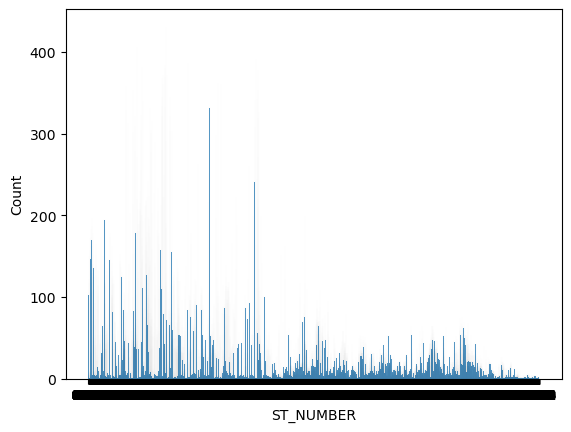

In [31]:
sns.histplot(df["ST_NUMBER"], bins=30)
plt.show()

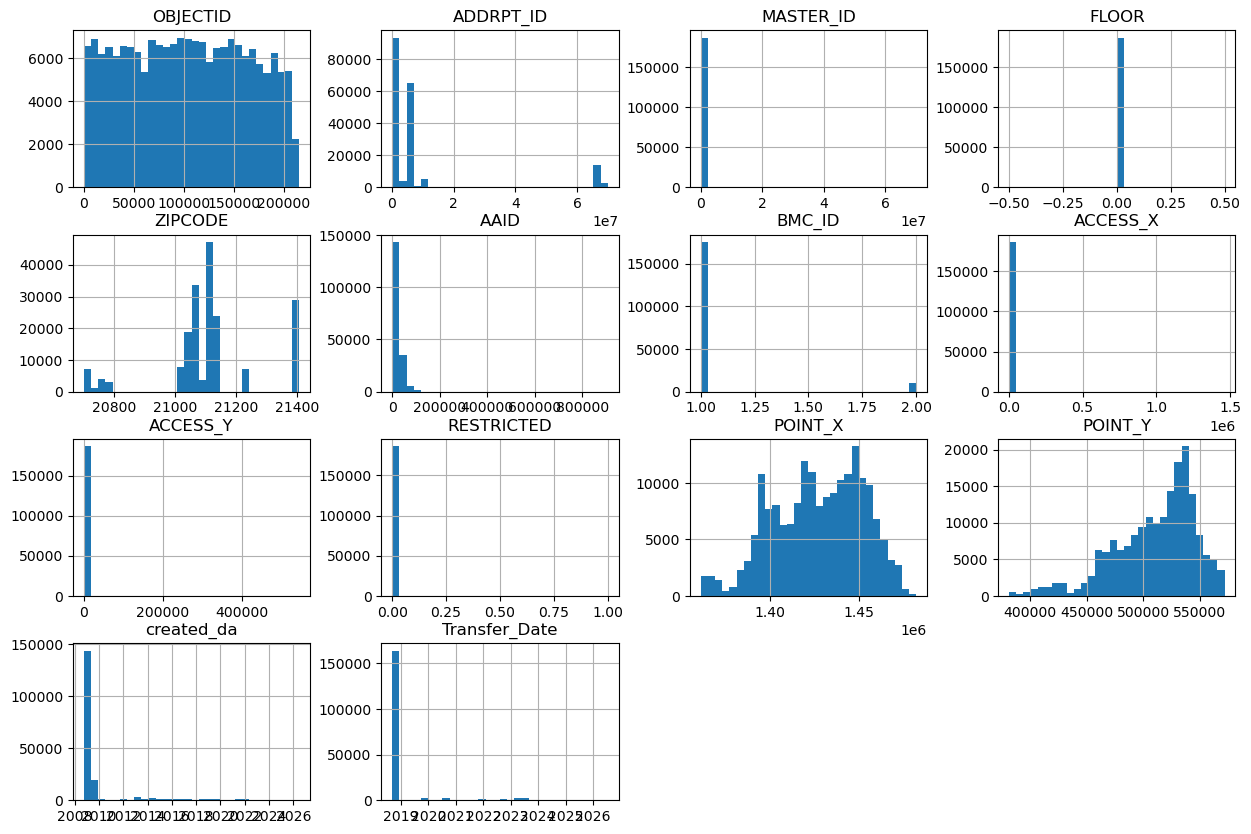

In [32]:
df.hist(figsize=(15,10), bins=30)
plt.show()

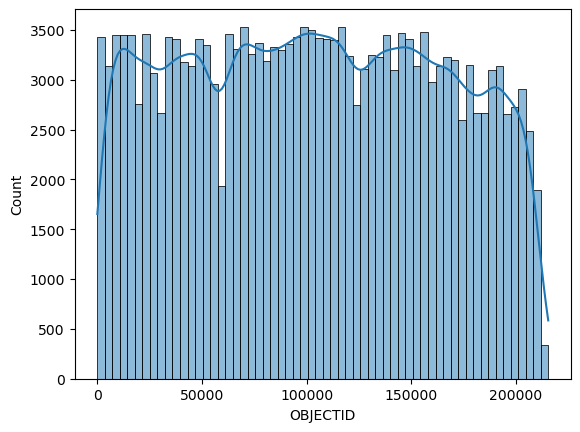

In [33]:
sns.histplot(df["OBJECTID"], kde=True)
plt.show()

In [34]:
df["FLOOR"].value_counts()

FLOOR
0    186419
Name: count, dtype: int64

In [35]:
df["ZIPCODE"].value_counts()

ZIPCODE
21122    22266
21061    14473
21144    12910
21060    12523
21401    11984
21113    10732
21146     9667
21403     9178
21037     8282
21012     7760
21114     7411
21409     7357
21108     6795
21076     6165
21225     5368
20724     5230
21054     4343
21090     3577
21032     3429
21035     2858
20764     1976
21226     1648
20711     1514
21140     1373
20733     1204
20751     1098
20776      982
20794      843
20778      775
20779      572
20714      449
21405      341
20754      310
20758      300
20765      213
21056      212
21077      134
20755      133
20736       33
20701        1
Name: count, dtype: int64

<Axes: xlabel='ZIPCODE'>

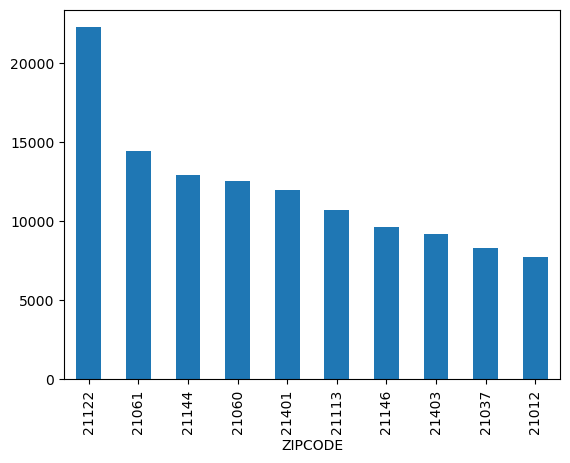

In [36]:
df["ZIPCODE"].value_counts().head(10).plot(kind="bar")

In [37]:
df["RESTRICTED"].value_counts()

RESTRICTED
0    186179
1       240
Name: count, dtype: int64

<Axes: xlabel='RESTRICTED', ylabel='count'>

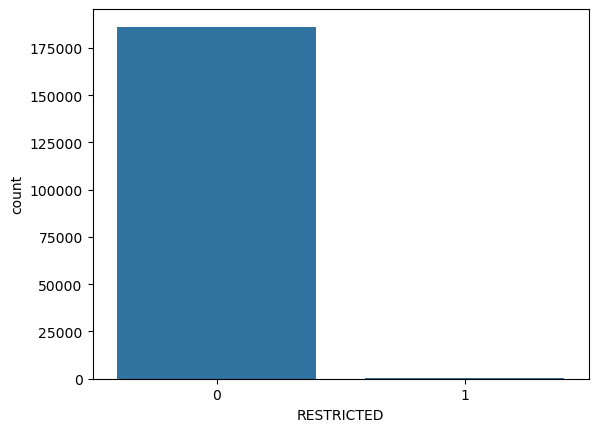

In [38]:
sns.countplot(data=df, x="RESTRICTED")

In [39]:
df["created_da"]= pd.to_datetime(df["created_da"])

In [40]:
df["year"] = df["created_da"].dt.year

In [41]:
df["Month"] = df["created_da"].dt.month_name()

<Axes: xlabel='year'>

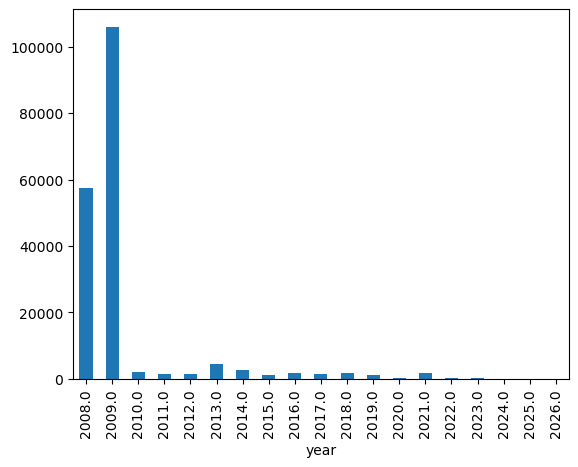

In [42]:
df["year"].value_counts().sort_index().plot(kind="bar")

In [43]:
df["Transfer_Date"].value_counts().sort_index()

Transfer_Date
2018-09-06        43
2018-09-11    151077
2018-09-13      1559
2018-09-17      5838
2018-09-18      4933
               ...  
2026-07-08         2
2026-07-09         2
2026-07-13        26
2026-07-14        79
2026-07-15         1
Name: count, Length: 714, dtype: int64

In [44]:
df["Transfer_Date"] = pd.to_datetime(df["Transfer_Date"])

<Axes: xlabel='Transfer_Date'>

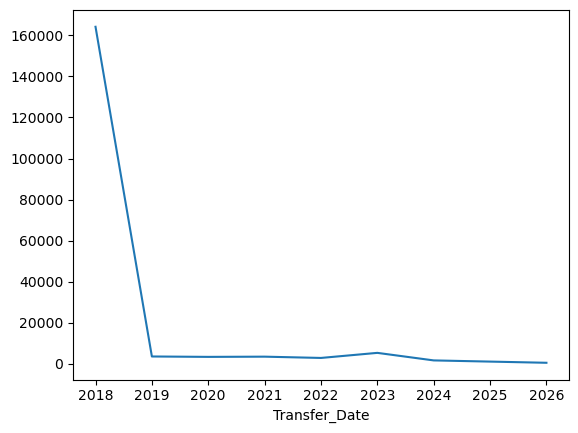

In [45]:
df["Transfer_Date"].dt.year.value_counts().sort_index().plot()

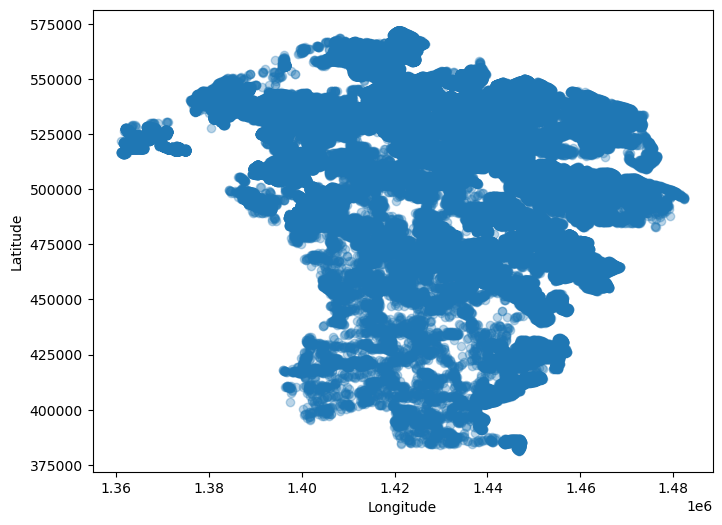

In [46]:
plt.figure(figsize=(8,6))

plt.scatter(df["POINT_X"],
            df["POINT_Y"],
            alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [47]:
df[["ACCESS_X","ACCESS_Y","POINT_X","POINT_Y"]].describe()

,ACCESS_X,ACCESS_Y,POINT_X,POINT_Y
count,1.864190e+05,186419.000000,1.864190e+05,186419.000000
mean,6.945531e+01,24.852127,1.427177e+06,510389.157925
std,9.996279e+03,3578.827892,2.508209e+04,36268.329607
min,0.000000e+00,0.000000,1.361096e+06,381414.369313
25%,0.000000e+00,0.000000,1.407465e+06,488541.589277
50%,0.000000e+00,0.000000,1.428890e+06,519159.421579
75%,0.000000e+00,0.000000,1.447584e+06,536719.909095
max,1.463883e+06,546247.806000,1.482353e+06,571886.985087


In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df.isnull().sum().sort_values(ascending=False)

Month            19
year             19
created_da       19
CAD_ADDR          0
BMC_ID            0
ACCESS_X          0
ACCESS_Y          0
BLDG_CODE         0
BLDG_ID           0
RESTRICTED        0
CAD_ST_TYP        0
POINT_X           0
COMMENTS          0
AAID              0
POINT_Y           0
STRUC_TYPE        0
GlobalID          0
created_us        0
last_edite        0
Transfer_Date     0
AA_CP             0
OBJECTID          0
ADDRPT_ID         0
ST_SUFFIXD        0
MASTER_ID         0
PT_TYPE           0
FULL_ADDRE        0
ST_NUMBER         0
ST_NUMSUFF        0
ST_PREFIXD        0
ST_NAME           0
ST_TYPE           0
BLDG_NAME         0
AA_POI            0
SOURCE            0
CITY_NAME         0
UNIT_TYPE         0
UNITNUM           0
FLOOR             0
UNIT_ADDR         0
SUB_ADDR          0
BUS_NAME          0
ZIPCODE           0
dtype: int64

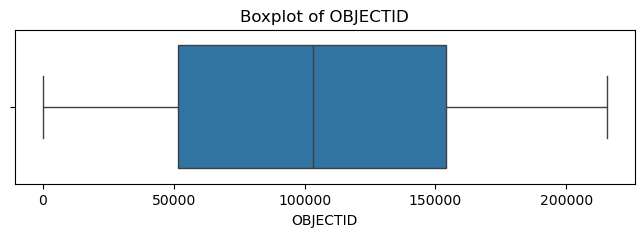

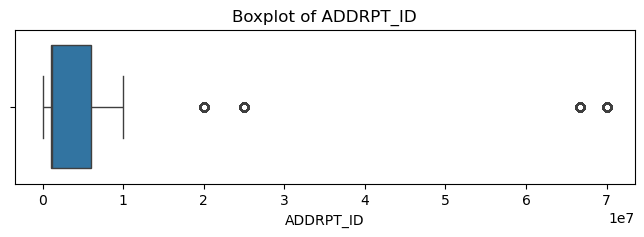

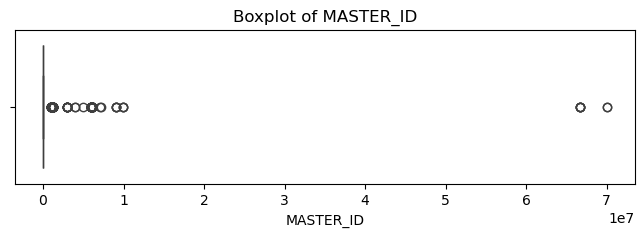

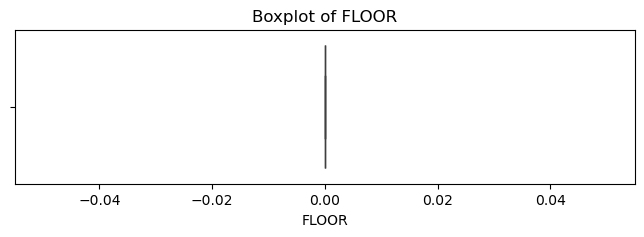

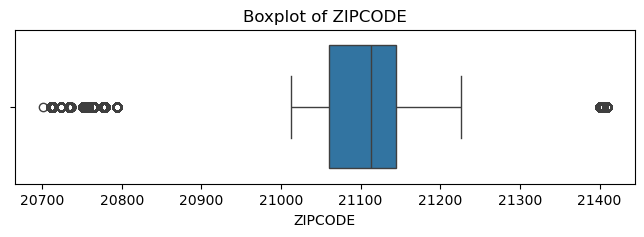

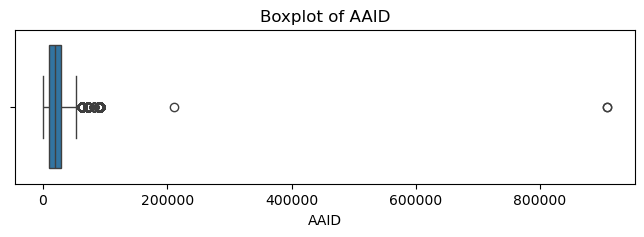

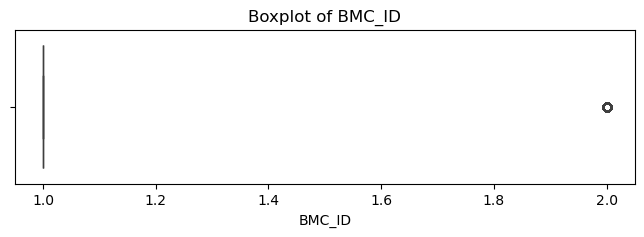

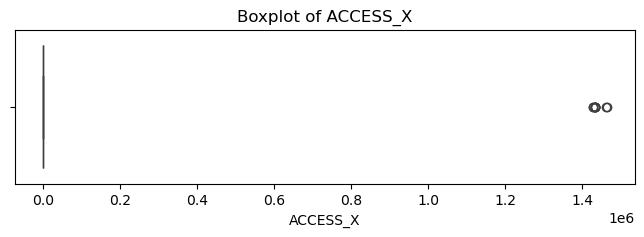

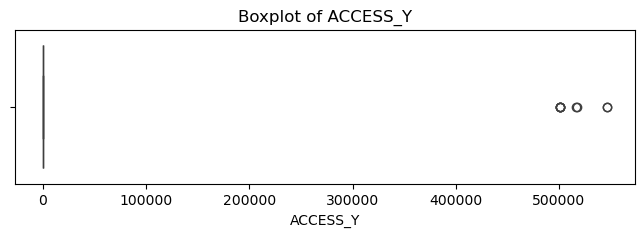

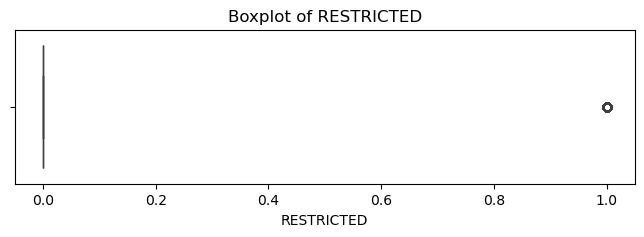

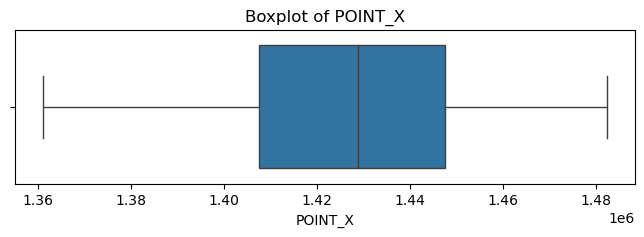

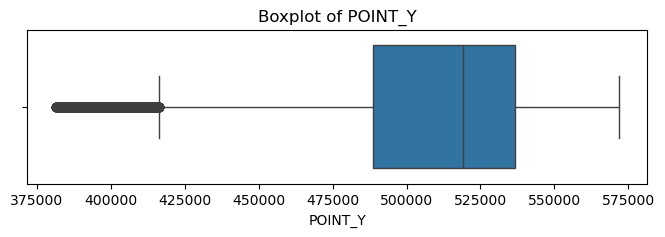

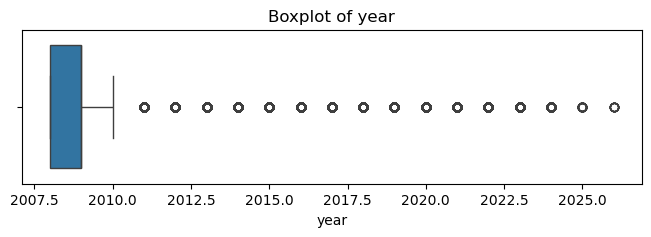

In [50]:
numeric_cols = df.select_dtypes(include=np.number).columns 

for col in numeric_cols:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

<Axes: >

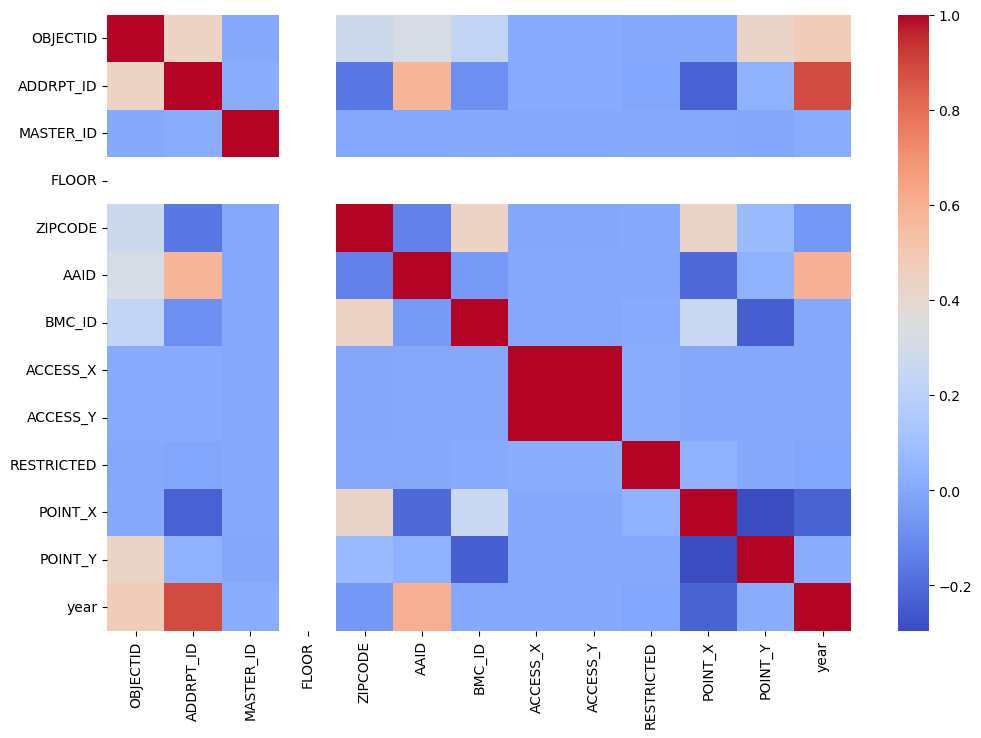

In [51]:
numeric = df.select_dtypes(include="number")

plt.figure(figsize=(12,8))

sns.heatmap(numeric.corr(),
            cmap="coolwarm")

# *phase 4:Outputs & Deliverables*
##### * Cleaned all missing values (Nulls) to reach 100% clean data.
##### * Investigated and fixed the "zero" values issue in the dataset , then Removed useless columns
##### * Visualized the cleaned data on a spatial map to ensure its geographic integrity 
##### * saved the final clean data into ( final_cleaned_data.csv)
##### * created a statistical summary table inside the code.
##### * Exported the summary automaticlly into an file called----> (executive_summary.txt)

In [52]:
df.shape

(186419, 43)

In [53]:
len(df)

186419

In [73]:
df.columns

Index(['OBJECTID', 'ADDRPT_ID', 'PT_TYPE', 'FULL_ADDRE', 'ST_NUMBER',
       'ST_NUMSUFF', 'ST_PREFIXD', 'ST_NAME', 'ST_TYPE', 'ST_SUFFIXD',
       'BLDG_NAME', 'SOURCE', 'CITY_NAME', 'UNIT_TYPE', 'UNITNUM', 'UNIT_ADDR',
       'SUB_ADDR', 'BUS_NAME', 'AA_POI', 'ZIPCODE', 'AAID', 'AA_CP', 'BMC_ID',
       'BLDG_CODE', 'BLDG_ID', 'CAD_ST_TYP', 'CAD_ADDR', 'COMMENTS', 'POINT_X',
       'POINT_Y', 'STRUC_TYPE', 'GlobalID', 'created_us', 'created_da',
       'last_edite', 'Transfer_Date', 'year', 'Month', 'Years_Owned', 'Score'],
      dtype='object')

In [15]:
#Check for duplicate rows in the final data
df.duplicated().sum()

np.int64(0)

In [16]:
#Check for missing values in GIS coordinates
df[['POINT_X', 'POINT_Y']].isnull().sum()

POINT_X    0
POINT_Y    0
dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186419 entries, 0 to 215461
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OBJECTID       186419 non-null  int64         
 1   ADDRPT_ID      186419 non-null  int64         
 2   MASTER_ID      186419 non-null  int64         
 3   PT_TYPE        186419 non-null  object        
 4   FULL_ADDRE     186419 non-null  object        
 5   ST_NUMBER      186419 non-null  object        
 6   ST_NUMSUFF     186419 non-null  object        
 7   ST_PREFIXD     186419 non-null  object        
 8   ST_NAME        186419 non-null  object        
 9   ST_TYPE        186419 non-null  object        
 10  ST_SUFFIXD     186419 non-null  object        
 11  BLDG_NAME      186419 non-null  object        
 12  SOURCE         186419 non-null  object        
 13  CITY_NAME      186419 non-null  object        
 14  UNIT_TYPE      186419 non-null  object        
 15  UNITN

In [18]:
#Drop the few rows where 'created_da' is missing
df = df.dropna(subset=['created_da'])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186400 entries, 0 to 215461
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OBJECTID       186400 non-null  int64         
 1   ADDRPT_ID      186400 non-null  int64         
 2   MASTER_ID      186400 non-null  int64         
 3   PT_TYPE        186400 non-null  object        
 4   FULL_ADDRE     186400 non-null  object        
 5   ST_NUMBER      186400 non-null  object        
 6   ST_NUMSUFF     186400 non-null  object        
 7   ST_PREFIXD     186400 non-null  object        
 8   ST_NAME        186400 non-null  object        
 9   ST_TYPE        186400 non-null  object        
 10  ST_SUFFIXD     186400 non-null  object        
 11  BLDG_NAME      186400 non-null  object        
 12  SOURCE         186400 non-null  object        
 13  CITY_NAME      186400 non-null  object        
 14  UNIT_TYPE      186400 non-null  object        
 15  UNITN

In [20]:
df.describe()

,OBJECTID,ADDRPT_ID,MASTER_ID,FLOOR,ZIPCODE,AAID,BMC_ID,ACCESS_X,ACCESS_Y,RESTRICTED,POINT_X,POINT_Y,created_da,Transfer_Date
count,186400.000000,1.864000e+05,1.864000e+05,186400.0,186400.000000,186400.000000,186400.000000,1.864000e+05,186400.000000,186400.000000,1.864000e+05,186400.000000,186400,186400
mean,103489.801765,9.177859e+06,5.844322e+03,0.0,21115.273766,22403.811406,1.057865,6.946239e+01,24.854660,0.001288,1.427176e+06,510388.381412,2009-11-16 21:41:49.030043136,2019-02-13 21:45:02.317596672
min,1.000000,4.212200e+04,0.000000e+00,0.0,20701.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,1.361096e+06,381414.369313,2008-09-30 00:00:00,2018-09-06 00:00:00
25%,51521.750000,1.080479e+06,0.000000e+00,0.0,21060.000000,9702.000000,1.000000,0.000000e+00,0.000000,0.000000,1.407461e+06,488538.509478,2008-12-10 00:00:00,2018-09-11 00:00:00
50%,103134.500000,1.184997e+06,0.000000e+00,0.0,21113.000000,19613.000000,1.000000,0.000000e+00,0.000000,0.000000,1.428887e+06,519160.593164,2009-02-02 00:00:00,2018-09-11 00:00:00
75%,154123.250000,6.050564e+06,0.000000e+00,0.0,21144.000000,29560.250000,1.000000,0.000000e+00,0.000000,0.000000,1.447585e+06,536721.946165,2009-04-21 00:00:00,2018-09-11 00:00:00
max,215462.000000,7.001556e+07,7.000288e+07,0.0,21409.000000,907324.000000,2.000000,1.463883e+06,546247.806000,1.000000,1.482353e+06,571886.985087,2026-07-01 00:00:00,2026-07-15 00:00:00
std,59934.464006,1.849014e+07,4.333057e+05,0.0,163.122561,17701.588930,0.233488,9.996789e+03,3579.010277,0.035859,2.508332e+04,36270.064751,NaN,NaN


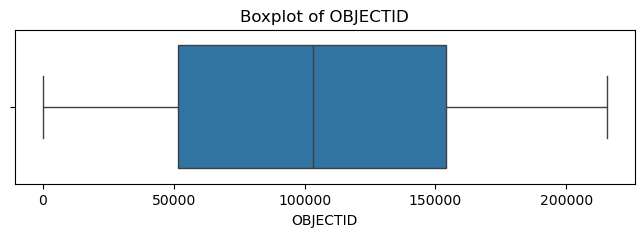

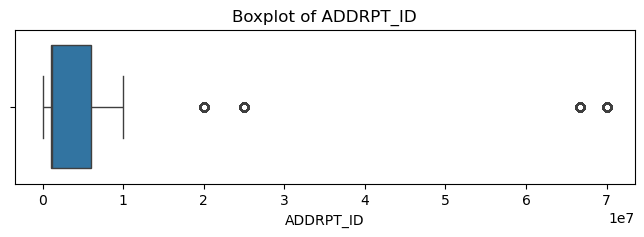

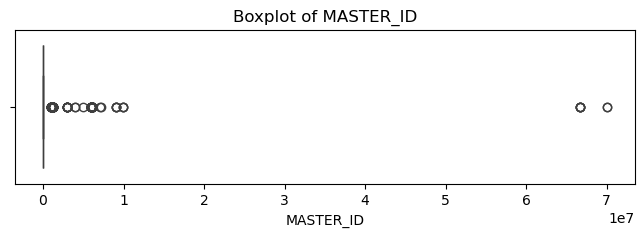

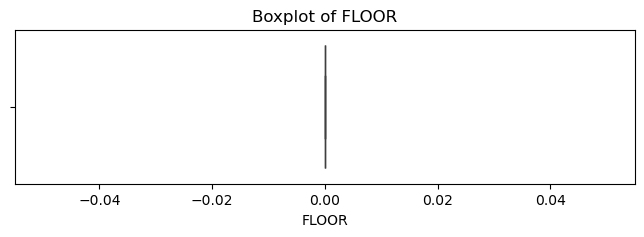

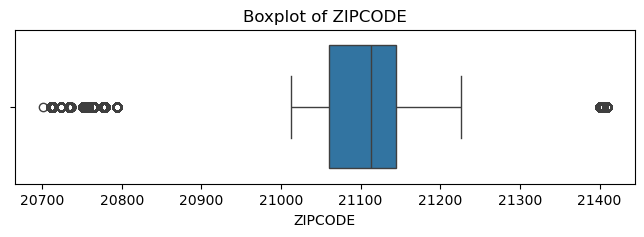

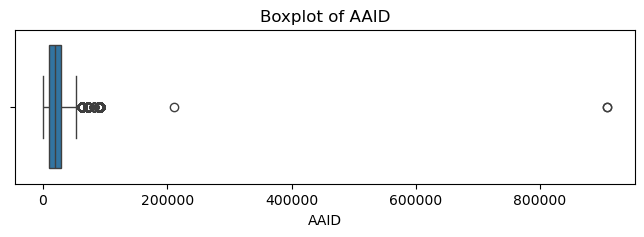

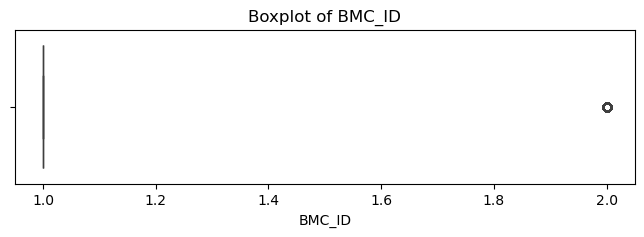

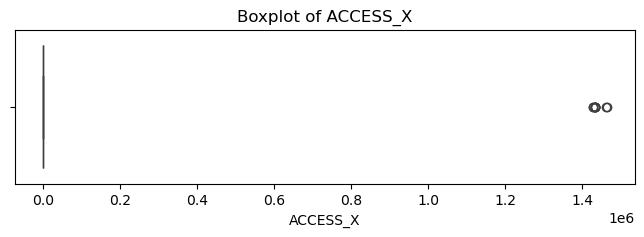

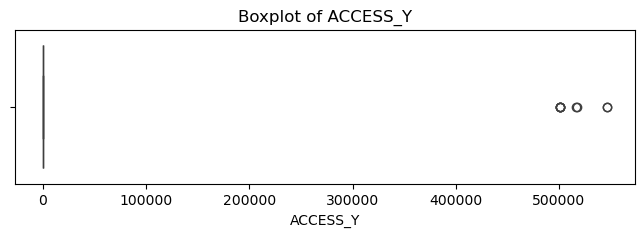

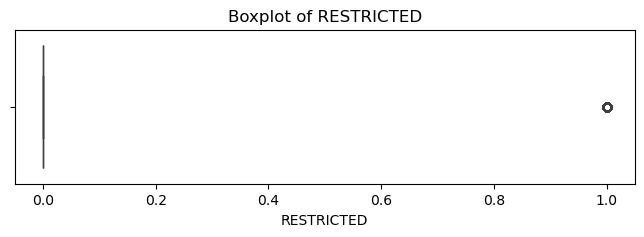

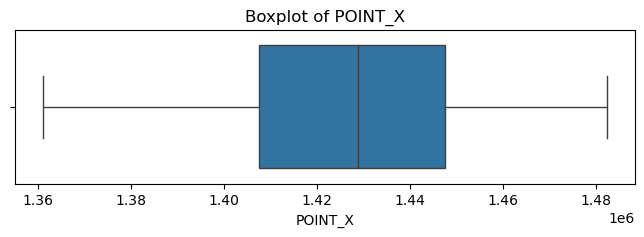

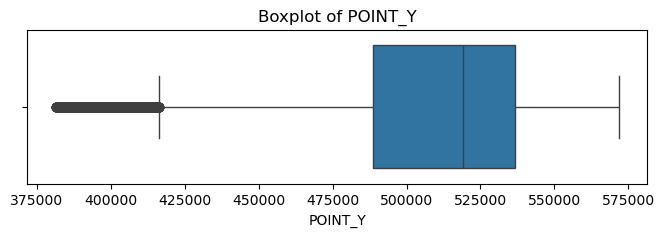

In [21]:
numeric_cols = df.select_dtypes(include=np.number).columns 

for col in numeric_cols:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [22]:
#Count zeros in columns
(df == 0).sum()

OBJECTID              0
ADDRPT_ID             0
MASTER_ID        186158
PT_TYPE               0
FULL_ADDRE            0
ST_NUMBER             0
ST_NUMSUFF            0
ST_PREFIXD            0
ST_NAME               0
ST_TYPE               0
ST_SUFFIXD            0
BLDG_NAME             0
SOURCE                0
CITY_NAME             0
UNIT_TYPE             0
UNITNUM               0
FLOOR            186400
UNIT_ADDR             0
SUB_ADDR              0
BUS_NAME              0
AA_POI                0
ZIPCODE               0
AAID                  0
AA_CP                 0
BMC_ID                0
ACCESS_X         186391
ACCESS_Y         186391
BLDG_CODE             0
BLDG_ID               0
RESTRICTED       186160
CAD_ST_TYP            0
CAD_ADDR              0
COMMENTS              0
POINT_X               0
POINT_Y               0
STRUC_TYPE            0
GlobalID              0
created_us            0
created_da            0
last_edite            0
Transfer_Date         0
dtype: int64

In [23]:
df.head()

,OBJECTID,ADDRPT_ID,MASTER_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,FLOOR,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,ACCESS_X,ACCESS_Y,BLDG_CODE,BLDG_ID,RESTRICTED,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,Transfer_Date
0,1,6001687,0,ADDRESS,"625 IRVIN AVE, 20751",625,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,625 IRVIN AV,ADDED PT_TYPE,1.439284e+06,402495.290406,SFD,{AD593BB0-D3B1-4402-B822-8529BEC782F5},,2008-10-24,GIS_AnneArundel,2025-03-13
1,2,6001692,0,ADDRESS,"626 IRVIN AVE, 20751",626,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,626 IRVIN AV,,1.439212e+06,402767.288550,SFD,{8C470E52-DD05-4884-AAED-A9B3F060337E},,2008-10-24,pzmagl22,2025-02-25
2,3,6001700,0,ADDRESS,"615 IRVIN AVE, 20751",615,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,615 IRVIN AV,,1.439111e+06,402678.746732,SFD,{CE191B44-8EE1-4B41-9539-AD397FAE1ADE},,2008-10-24,ITMAGL23,2020-07-27
3,4,6001704,0,ADDRESS,"622 IRVIN AVE, 20751",622,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,622 IRVIN AV,,1.439271e+06,402690.877941,SFD,{0B96BC79-B362-40E8-B72D-1EE555758B72},,2008-10-24,ITMAGL23,2020-07-27
4,5,6001709,0,ADDRESS,"624 IRVIN AVE, 20751",624,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,624 IRVIN AV,,1.439239e+06,402729.958244,SFD,{BF8ED993-907C-4A16-B868-5D595E287181},,2008-10-24,ITMAGL23,2020-07-27


In [24]:
df.sample(5)

,OBJECTID,ADDRPT_ID,MASTER_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,FLOOR,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,ACCESS_X,ACCESS_Y,BLDG_CODE,BLDG_ID,RESTRICTED,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,Transfer_Date
109427,109428,1147359,0,ADDRESS,"8051 STONE HAVEN DR, 21060",8051,,,STONE HAVEN,DR,,,PHYSICALLY VERIFIED IN FIELD,GLEN BURNIE,,,0,,,,N,21060,29976,N,1,0.0,0.0,RESIDENTIAL,,0,DR,8051 STONE HAVEN DR,,1.437500e+06,538635.170029,SFD,{24027D55-1431-4C26-9018-085CD46A4F6D},,2008-11-26,ITVMAN00,2018-09-11
93137,93138,1043327,0,ADDRESS,"707 CROSS ST, 21225",707,,,CROSS,ST,,,PHYSICALLY VERIFIED IN FIELD,BROOKLYN,,,0,,,,N,21225,14338,N,1,0.0,0.0,RESIDENTIAL,,0,ST,707 CROSS ST,,1.425320e+06,567163.183511,SFD,{14DE1CCE-A0A8-4B73-872D-9D77ADEA7E66},,2008-10-29,ITVMAN00,2018-09-11
24822,24823,6025637,0,ADDRESS,"1430 KNIGHTSBRIDGE TURN, 21114",1430,,,KNIGHTSBRIDGE TURN,,,,INFERRED FROM OTHER SOURCES,CROFTON,,,0,,,,N,21114,26325,N,1,0.0,0.0,RESIDENTIAL,,0,,1430 KNIGHTSBRIDGE TURN,CHANGED ST_NAME FROM KNIGHTS BRIDGE TURN TO KN...,1.404579e+06,486469.848507,SFD,{B99746B3-5AFD-4D75-A7EC-01E260E83A17},,2009-02-27,ITVMAN00,2018-09-11
4766,4767,6005205,0,ADDRESS,"1008 JUDGE CT W, 20778",1008,,,JUDGE,CT,W,,PHYSICALLY VERIFIED IN FIELD,WEST RIVER,,,0,,,,N,20778,28776,N,1,0.0,0.0,RESIDENTIAL,,0,CT,1008 JUDGE CT W,,1.444204e+06,420533.171653,SFD,{EC9581BC-BB94-4EC8-9057-E4EE17F737A7},,2008-12-09,ITVMAN00,2018-09-11
89881,89882,1160071,0,ADDRESS,"1002 CEDAR RIDGE CT, 21403",1002,,,CEDAR RIDGE,CT,,,PHYSICALLY VERIFIED IN FIELD,ANNAPOLIS,,,0,,,,N,21403,15642,N,2,0.0,0.0,RESIDENTIAL,,0,CT,1002 CEDAR RIDGE CT,,1.456494e+06,470740.504637,SFA,{FB41D923-C4DA-4BA3-AC21-95F23ADB16A9},,2009-04-08,ITSINE23,2018-09-17


In [25]:
#check the number of zeros in columns
(df[['FLOOR', 'ACCESS_X', 'ACCESS_Y', 'MASTER_ID', 'RESTRICTED']]==0).sum()

FLOOR         186400
ACCESS_X      186391
ACCESS_Y      186391
MASTER_ID     186158
RESTRICTED    186160
dtype: int64

In [26]:
# Drop columns that are entirely or mostly filled with zeros 
df = df.drop(columns=['FLOOR', 'ACCESS_X', 'ACCESS_Y', 'MASTER_ID', 'RESTRICTED'])

In [67]:
df.head()

,OBJECTID,ADDRPT_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,BLDG_CODE,BLDG_ID,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,Transfer_Date,year,Month
0,1,6001687,ADDRESS,"625 IRVIN AVE, 20751",625,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,,,,N,20751,6371,N,1,RESIDENTIAL,,AV,625 IRVIN AV,ADDED PT_TYPE,1.439284e+06,402495.290406,SFD,{AD593BB0-D3B1-4402-B822-8529BEC782F5},,2008-10-24,GIS_AnneArundel,2025-03-13,2008.0,October
1,2,6001692,ADDRESS,"626 IRVIN AVE, 20751",626,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,,,,N,20751,6371,N,1,RESIDENTIAL,,AV,626 IRVIN AV,,1.439212e+06,402767.288550,SFD,{8C470E52-DD05-4884-AAED-A9B3F060337E},,2008-10-24,pzmagl22,2025-02-25,2008.0,October
2,3,6001700,ADDRESS,"615 IRVIN AVE, 20751",615,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,,,,N,20751,6371,N,1,RESIDENTIAL,,AV,615 IRVIN AV,,1.439111e+06,402678.746732,SFD,{CE191B44-8EE1-4B41-9539-AD397FAE1ADE},,2008-10-24,ITMAGL23,2020-07-27,2008.0,October
3,4,6001704,ADDRESS,"622 IRVIN AVE, 20751",622,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,,,,N,20751,6371,N,1,RESIDENTIAL,,AV,622 IRVIN AV,,1.439271e+06,402690.877941,SFD,{0B96BC79-B362-40E8-B72D-1EE555758B72},,2008-10-24,ITMAGL23,2020-07-27,2008.0,October
4,5,6001709,ADDRESS,"624 IRVIN AVE, 20751",624,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,,,,N,20751,6371,N,1,RESIDENTIAL,,AV,624 IRVIN AV,,1.439239e+06,402729.958244,SFD,{BF8ED993-907C-4A16-B868-5D595E287181},,2008-10-24,ITMAGL23,2020-07-27,2008.0,October


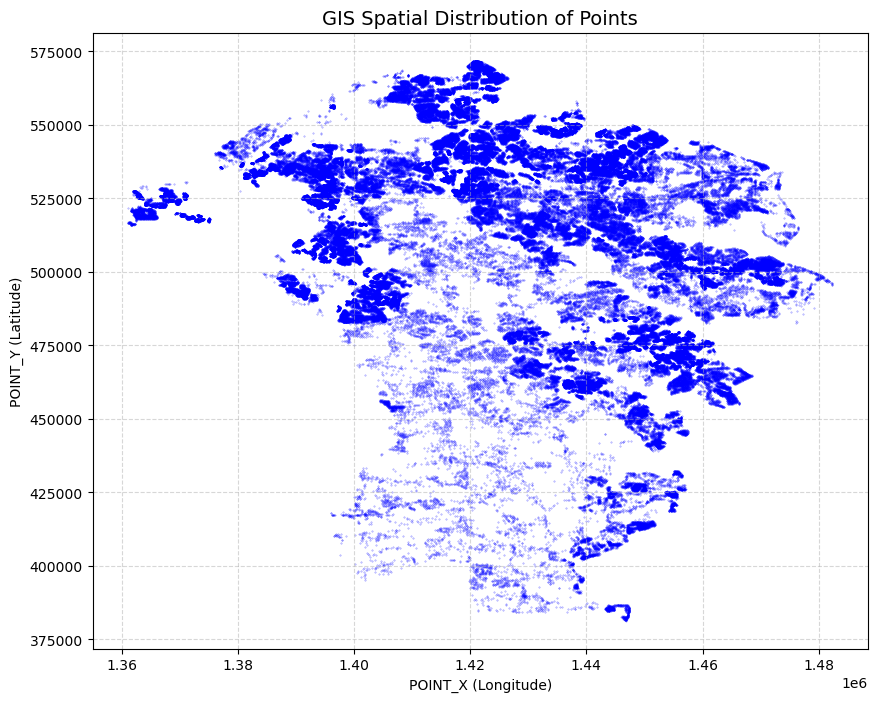

In [68]:
plt.figure(figsize=(10, 8))
plt.scatter(df['POINT_X'], df['POINT_Y'], s=0.1, color='blue', alpha=0.5)
plt.title('GIS Spatial Distribution of Points', fontsize=14)
plt.xlabel('POINT_X (Longitude)')
plt.ylabel('POINT_Y (Latitude)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [69]:
#Save the final cleaned dataset to a new CSV file
df.to_csv('final_cleaned_Anne_Arundel.csv', index=False)

In [70]:
print("==================================================")
print("             EXECUTIVE SUMMARY REPORT             ")
print("==================================================")

# 1. Total number of records (Rows and Columns)
print(f"Total Cleaned Records: {df.shape[0]} rows")
print(f"Total Useful Features: {df.shape[1]} columns")
print("-" * 50)

# 2. Statistical Summary for numerical columns
print("Descriptive Statistics for Key Numerical Data:")
print(df.describe().round(2))
print("-" * 50)

# 3. Check for any remaining missing values (Verification)
print("Missing values remaining in the dataset:")
print(df.isnull().sum().sum())
print("==================================================")

             EXECUTIVE SUMMARY REPORT             
Total Cleaned Records: 186400 rows
Total Useful Features: 38 columns
--------------------------------------------------
Descriptive Statistics for Key Numerical Data:
        OBJECTID    ADDRPT_ID    ZIPCODE       AAID     BMC_ID     POINT_X  \
count  186400.00    186400.00  186400.00  186400.00  186400.00   186400.00   
mean   103489.80   9177859.25   21115.27   22403.81       1.06  1427176.08   
min         1.00     42122.00   20701.00       1.00       1.00  1361095.62   
25%     51521.75   1080478.75   21060.00    9702.00       1.00  1407461.18   
50%    103134.50   1184997.00   21113.00   19613.00       1.00  1428886.88   
75%    154123.25   6050564.25   21144.00   29560.25       1.00  1447585.30   
max    215462.00  70015556.00   21409.00  907324.00       2.00  1482353.34   
std     59934.46  18490139.98     163.12   17701.59       0.23    25083.32   

         POINT_Y                     created_da  \
count  186400.00            

In [71]:
with open ('executive_summary.txt' , 'w' , encoding='utf-8 ') as f:
    f.write('========================================\n' )
    f.write('        EXECUTIVE SUMMARY REPORT            \n')
    f.write('========================================\n \n')

    # dataset dimentions
    f.write(f'Total Cleaned Records : {df.shape[0]:,} rows \n')
    f.write(f'Total Useful features : {df.shape[1]} columns \n')
    f.write ( '-' * 50 + '\n') 
    # null values check   
    remaining_nulls=df.isnull().sum().sum()
    f.write(f'Remaining missing values : { remaining_nulls} ( data is 100% clean. )\n')
    f.write('-'*50 + '\n \n ')
    # descriptive statistics table 
    f.write( 'Descriptive Statistics for key Numerical feature :\n')
    f.write ( df.describe() .to_string())
    f.write('\n \n =============================================')
    print('SUCESSSSSS')

SUCESSSSSS


In [ ]:
import datetime

# Calculate property ownership score based on transfer dates
current_year = 2026

df["Transfer_Date"] = pd.to_datetime(df["Transfer_Date"])
df["Years_Owned"] = current_year - df["Transfer_Date"].dt.year

max_years = df["Years_Owned"].max()
if max_years > 0:
    df["Score"] = ((df["Years_Owned"] / max_years) * 100).round(1)
else:
    df["Score"] = 0.0

df_final = df.sort_values(by="Score", ascending=False)

columns_to_save = [
    "FULL_ADDRE",
    "ZIPCODE",
    "POINT_X",
    "POINT_Y",
    "Transfer_Date",
    "Years_Owned",
    "Score"
] 

existing_columns = [col for col in columns_to_save if col in df_final.columns]

df_final[existing_columns].to_csv("Properties_Cold_Calling_List_with_Score.csv", index=False)
print("Done!")

Done!


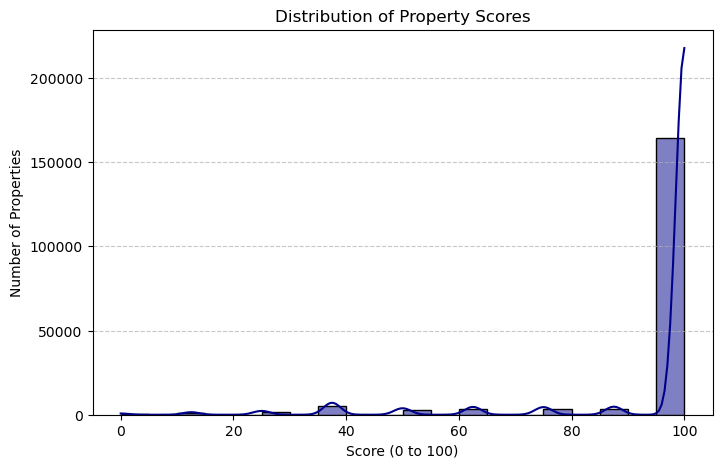

In [ ]:
# Plot the distribution of Scores 
plt.figure(figsize=(8, 5))

sns.histplot(data=df_final, x="Score", bins=20, kde=True, color="darkblue")

plt.title("Distribution of Property Scores")
plt.xlabel("Score (0 to 100)")
plt.ylabel("Number of Properties")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Generate a heat map of properties using dynamic coordinates
import folium
from folium.plugins import HeatMap

m = folium.Map(location=[39.0, -76.6], zoom_start=10)
heat_data = df_final[['POINT_Y', 'POINT_X']].dropna().values.tolist()

HeatMap(heat_data, radius=12, blur=8, max_zoom=13).add_to(m)

m.save("Anne_Arundel_Hotspots_Map.html")
print("Done!")

Done!


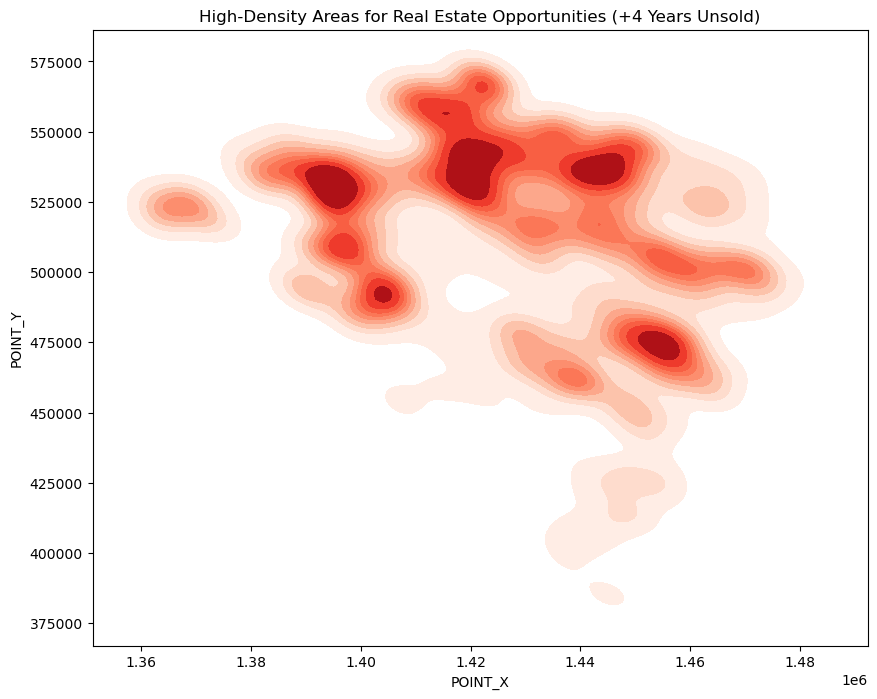

In [78]:
# Generate and plot a static 2D density map of properties
plt.figure(figsize=(10, 8))

sns.kdeplot(
    data=df, 
    x="POINT_X", 
    y="POINT_Y", 
    cmap="Reds", 
    fill=True, 
    thresh=0.05
)

plt.title("High-Density Areas for Real Estate Opportunities (+4 Years Unsold)")
plt.show()

In [31]:
print("أقدم تاريخ ف الداتا:", df["Transfer_Date"].min())
print("أحدث تاريخ ف الداتا:", df["Transfer_Date"].max())

أقدم تاريخ ف الداتا: 2018-09-06 00:00:00
أحدث تاريخ ف الداتا: 2026-07-15 00:00:00


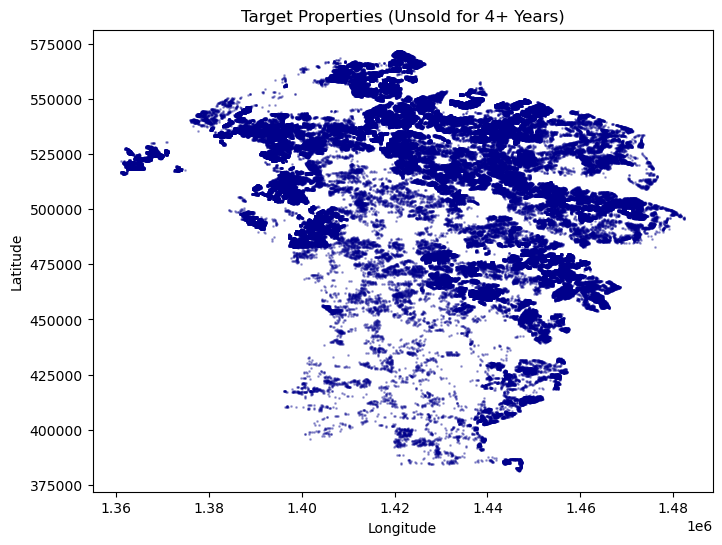

In [80]:
#  Filter for properties unsold for 4+ years
leads_df = df[df["Transfer_Date"] <= "2022-07-14"]

#  Plot the map of target properties
plt.figure(figsize=(8, 6))
plt.scatter(leads_df["POINT_X"], leads_df["POINT_Y"], color="darkblue", alpha=0.3, s=1)

plt.title("Target Properties (Unsold for 4+ Years)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Save filtered data to CSV
leads_df.to_csv("properties_leads.csv", index=False)

In [37]:
df.describe()

,OBJECTID,ADDRPT_ID,ZIPCODE,AAID,BMC_ID,POINT_X,POINT_Y,created_da,Transfer_Date,Years_Owned,Score
count,186400.000000,1.864000e+05,186400.000000,186400.000000,186400.000000,1.864000e+05,186400.000000,186400,186400,186400.000000,186400.000000
mean,103489.801765,9.177859e+06,21115.273766,22403.811406,1.057865,1.427176e+06,510388.381412,2009-11-16 21:41:49.030043136,2019-02-13 21:45:02.317596672,7.559506,94.493830
min,1.000000,4.212200e+04,20701.000000,1.000000,1.000000,1.361096e+06,381414.369313,2008-09-30 00:00:00,2018-09-06 00:00:00,0.000000,0.000000
25%,51521.750000,1.080479e+06,21060.000000,9702.000000,1.000000,1.407461e+06,488538.509478,2008-12-10 00:00:00,2018-09-11 00:00:00,8.000000,100.000000
50%,103134.500000,1.184997e+06,21113.000000,19613.000000,1.000000,1.428887e+06,519160.593164,2009-02-02 00:00:00,2018-09-11 00:00:00,8.000000,100.000000
75%,154123.250000,6.050564e+06,21144.000000,29560.250000,1.000000,1.447585e+06,536721.946165,2009-04-21 00:00:00,2018-09-11 00:00:00,8.000000,100.000000
max,215462.000000,7.001556e+07,21409.000000,907324.000000,2.000000,1.482353e+06,571886.985087,2026-07-01 00:00:00,2026-07-15 00:00:00,8.000000,100.000000
std,59934.464006,1.849014e+07,163.122561,17701.588930,0.233488,2.508332e+04,36270.064751,NaN,NaN,1.362283,17.028535
